In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("bikekharido_used_bikes_cleaned.csv")
df

,bike_name,price,km_driven,ownership,location
0,Activa 3G STD,25000,60000.0,First,Mumbai
1,Maestro Edge 110 Drum Brake Alloy Wheel FI,34000,28000.0,Third,Jaipur
2,XPulse 200 4V,95000,25000.0,Second,Mumbai
3,S1 X,75000,2250.0,First,Kolkata
4,Karizma R,16000,100000.0,First,Hyderabad
...,...,...,...,...,...
592,2013 Suzuki Access 125 Drum Alloy Bluetooth,30000,20000.0,Second,Ahmadnagar
593,2019 KTM Duke 390 2017 Edition1,160000,21500.0,Above,Mumbai
594,2019 Bajaj Dominar 400 BS4,150000,20000.0,Second,Mumbai
595,2010 TVS Apache RTR 180,18000,80000.0,Third,Mumbai


#### Exploratory Data Analysis
**EDA Question 1: What is the distribution of bike prices?**

In [3]:
print("Minimum Price:", df["price"].min())
print("Maximum Price:", df["price"].max())
print("Average Price:", round(df["price"].mean(), 2))
print("Median Price:", df["price"].median())

Minimum Price: 10000
Maximum Price: 900000
Average Price: 97082.14
Median Price: 75000.0


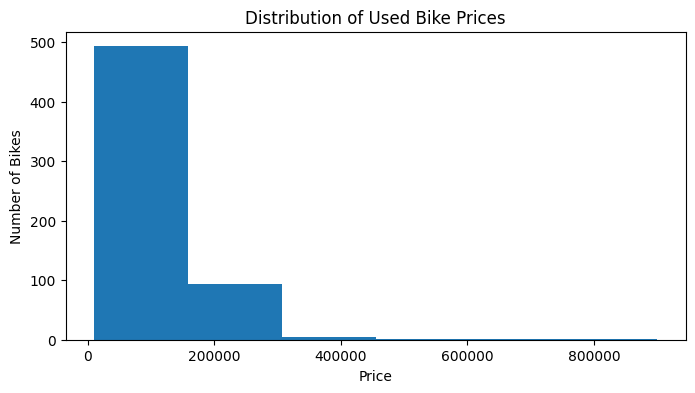

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df["price"],bins=6)
plt.xlabel("Price")
plt.ylabel("Number of Bikes")
plt.title("Distribution of Used Bike Prices")
plt.show()

**EDA Question 2: Which locations have the most used-bike listings?**

In [5]:
location_counts = df["location"].value_counts()

print(location_counts)

location
Delhi            108
Mumbai            61
Bangalore         57
Pune              43
Hyderabad         38
                ... 
Visakhapatnam      1
Tezpur             1
Jalandhar          1
Thrissur           1
Ahmadnagar         1
Name: count, Length: 97, dtype: int64


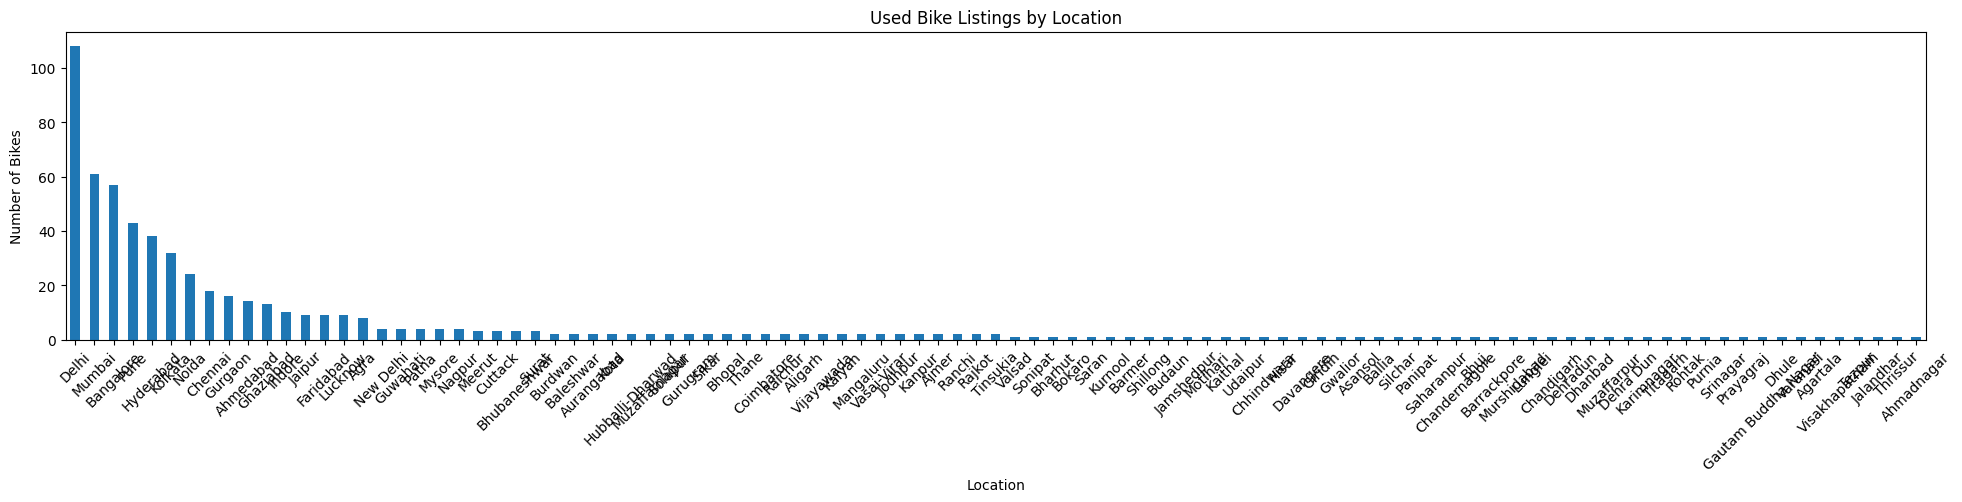

In [58]:
plt.figure(figsize=(24,4))

location_counts.plot(kind="bar")

plt.xlabel("Location")
plt.ylabel("Number of Bikes")
plt.title("Used Bike Listings by Location")
plt.xticks(rotation=45)
plt.show()

**EDA Question 3 — What is the average bike price by location?**

In [7]:
avg_price_location = df.groupby("location")["price"].mean().sort_values(ascending=False)

print(avg_price_location)

location
Ajmer            490000.0
Visakhapatnam    295000.0
Gwalior          270000.0
Aurangabad       210000.0
Coimbatore       190000.0
                   ...   
Barrackpore       26500.0
Agartala          24000.0
Kurnool           22000.0
Dhule             20000.0
Chhindwara        20000.0
Name: price, Length: 97, dtype: float64


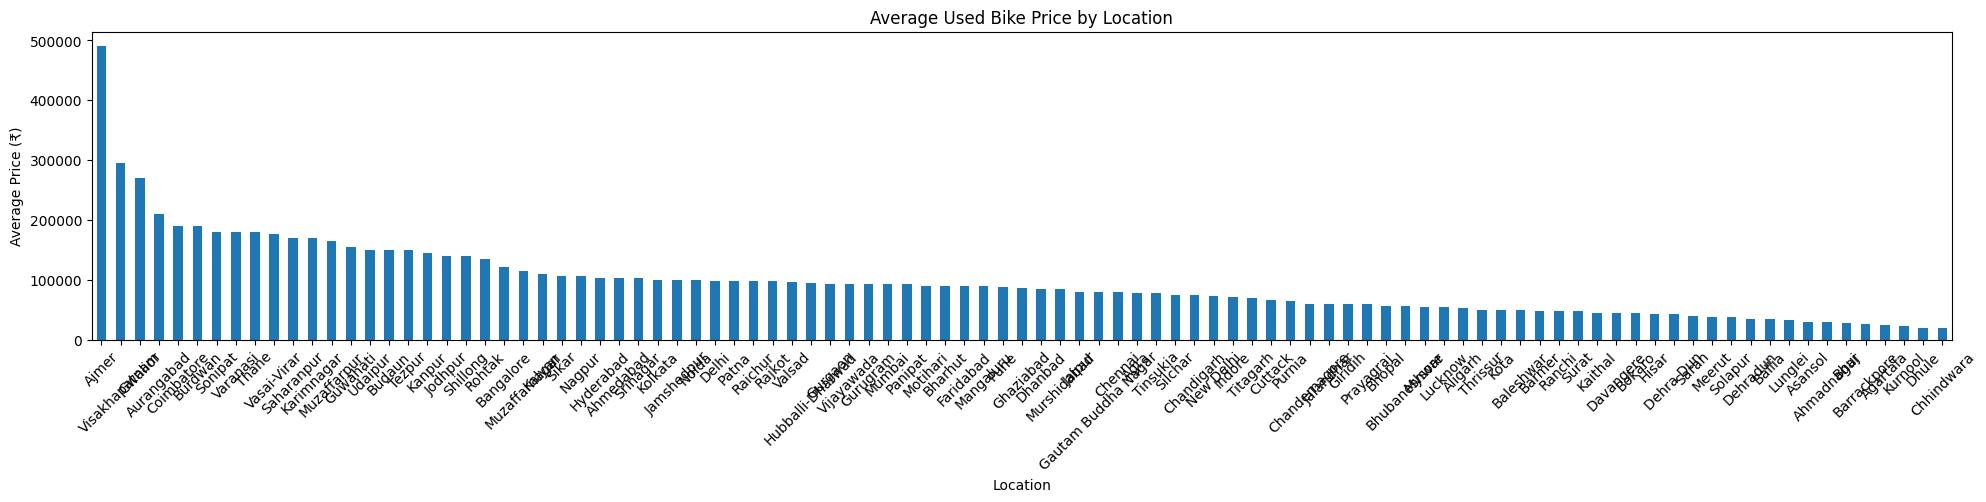

In [57]:
plt.figure(figsize=(24, 4))

avg_price_location.plot(kind="bar")

plt.xlabel("Location")
plt.ylabel("Average Price (₹)")
plt.title("Average Used Bike Price by Location")
plt.xticks(rotation=45)
plt.show()

**EDA Question 4 — What is the distribution of bike ownership?**

In [9]:
ownership_counts = df["ownership"].value_counts()

print(ownership_counts)

ownership
First     493
Second     83
Third      16
Above       5
Name: count, dtype: int64


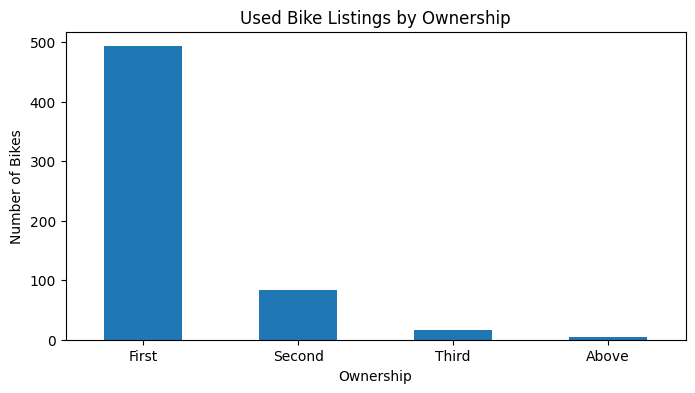

In [51]:
plt.figure(figsize=(8, 4))

ownership_counts.plot(kind="bar")

plt.xlabel("Ownership")
plt.ylabel("Number of Bikes")
plt.title("Used Bike Listings by Ownership")
plt.xticks(rotation=0)
plt.show()

**EDA Question 5 — How does ownership affect the average bike price?**

In [11]:
avg_price_ownership = df.groupby("ownership")["price"].mean().sort_values(ascending=False)

print(avg_price_ownership)

ownership
First     98282.225152
Above     92000.000000
Second    91690.361446
Third     89662.437500
Name: price, dtype: float64


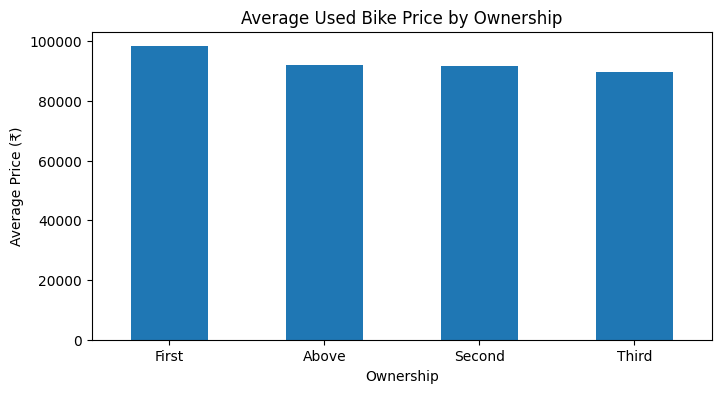

In [50]:
plt.figure(figsize=(8, 4))

avg_price_ownership.plot(kind="bar")

plt.xlabel("Ownership")
plt.ylabel("Average Price (₹)")
plt.title("Average Used Bike Price by Ownership")
plt.xticks(rotation=0)
plt.show()

**EDA Question 6 — Is there a relationship between KM driven and price?**

In [13]:
print(df[["km_driven", "price"]].corr())

           km_driven     price
km_driven   1.000000 -0.309025
price      -0.309025  1.000000


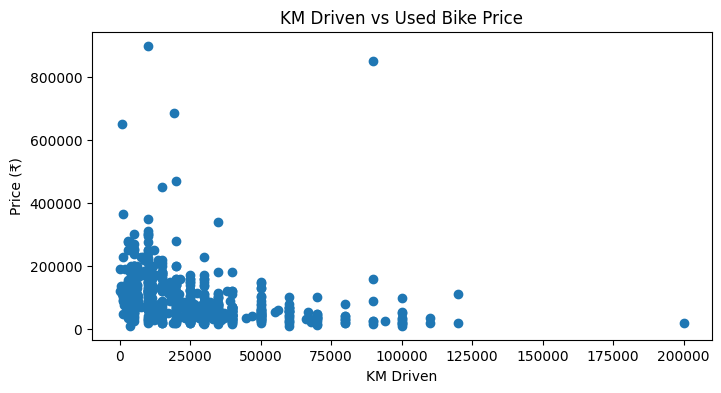

In [49]:
plt.figure(figsize=(8,4))

plt.scatter(df["km_driven"], df["price"])

plt.xlabel("KM Driven")
plt.ylabel("Price (₹)")
plt.title("KM Driven vs Used Bike Price")
plt.show()

**EDA Question 7 — Highest-Priced Bikes**

In [15]:
df[["bike_name", "price"]].sort_values("price", ascending=False).head(5)

,bike_name,price
32,SR125,900000
196,2023 Hero Splendor Plus i3s,850000
231,2015 Ducati Monster 795 STD,685000
456,2022 Kawasaki Z650RS,650000
213,2019 Benelli TNT 600i BS4 ABS BS4,470000


**EDA Question 8 — Lowest-priced bikes**

In [16]:
df[["bike_name", "price"]].sort_values("price").head(5)

,bike_name,price
321,2011 Hero Honda CD Dawn,10000
68,2012 Bajaj CT100 Spoke BS4,10203
57,2025 Yamaha RayZR 125 Fi Hybrid,10500
159,2012 Hero Maestro 110cc,12000
6,Dio Repsol Edition,15000


**EDA Question 9 — Average KM driven by ownership**

In [17]:
df.groupby("ownership")["km_driven"].mean().sort_values(ascending=False)

ownership
Above     49300.000000
Third     45718.750000
Second    32278.060241
First     25359.391481
Name: km_driven, dtype: float64

**EDA Question 10 — Price range by location**

In [18]:
df.groupby("location")["price"].agg(["min", "max", "mean"])

,min,max,mean
location,,,
Agartala,24000,24000,24000.000000
Agra,17000,180000,78000.000000
Ahmadnagar,30000,30000,30000.000000
Ahmedabad,35000,230000,102285.714286
Ajmer,80000,900000,490000.000000
...,...,...,...
Valsad,96870,96870,96870.000000
Varanasi,180000,180000,180000.000000
Vasai-Virar,77000,275000,176000.000000


**EDA Question 11 — Which bikes have the highest mileage?**

In [19]:
df[["bike_name", "km_driven"]].sort_values("km_driven", ascending=False).head(5)

,bike_name,km_driven
326,2011 Suzuki Access 125 Drum Brake CBS Special ...,200000.0
146,2014 Royal Enfield Bullet 350 ES ABS BS4,120000.0
494,2011 TVS Wego,120000.0
107,2012 TVS Apache RTR 160 Disc,110000.0
260,2017 Yamaha FZ S FI (V 2.0) STD,110000.0


**Insight:**

- Karizma R has the highest mileage at 100,000 km.
- Dio Repsol Edition follows with 90,000 km.
- Dio BS4 Dio has 70,000 km.
- Activa 3G STD has 60,000 km.
- Most of the highest-mileage bikes are also among the lower-priced listings, which is consistent with the negative KM–price relationship observed earlier.

**EDA Question 12 — Price distribution by ownership**

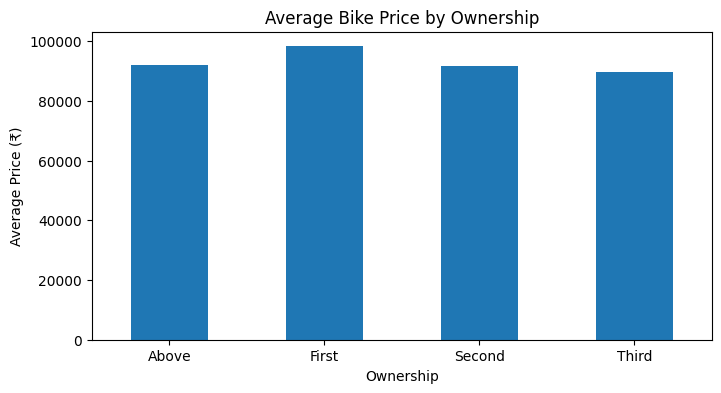

In [48]:
df.groupby("ownership")["price"].mean().plot(kind="bar", figsize=(8,4))
plt.xlabel("Ownership")
plt.ylabel("Average Price (₹)")
plt.title("Average Bike Price by Ownership")
plt.xticks(rotation=0)
plt.show()

**Q13. Which bike models appear most frequently in the dataset?**

In [21]:
bike_counts = df["bike_name"].value_counts().head(10)
print(bike_counts)

bike_name
2021 Jawa Perak                                      5
2016 Honda Activa 3G STD                             4
2022 Yezdi Roadster                                  4
2022 Revolt RV400                                    4
2019 Royal Enfield Interceptor 650 Silver Spectre    3
2012 Honda Activa                                    3
2021 Suzuki Gixxer                                   3
2017 Bajaj Pulsar NS160 STD                          3
2023 Royal Enfield Hunter 350 Metro Rebel            3
2019 Royal Enfield Thunderbird 350X ABS              3
Name: count, dtype: int64


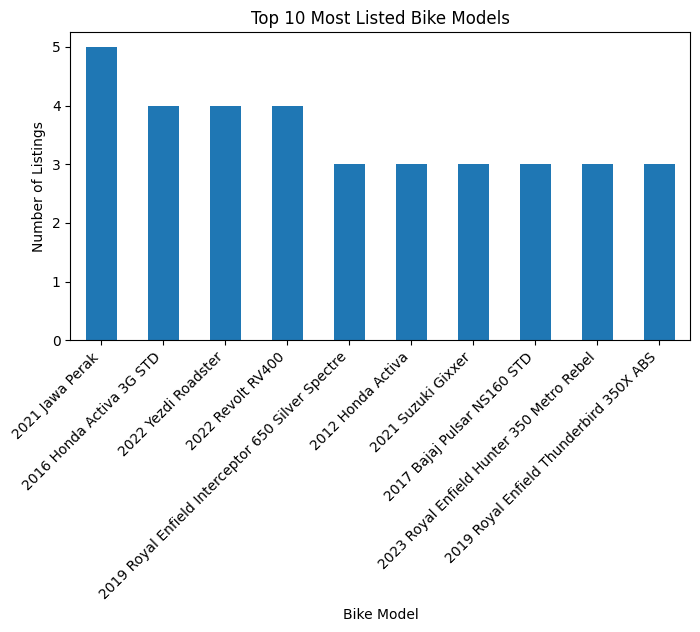

In [24]:
bike_counts.plot(kind="bar", figsize=(8, 4))
plt.title("Top 10 Most Listed Bike Models")
plt.xlabel("Bike Model")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45, ha="right")
plt.show()

**Q14. What is the average price for each ownership category?**

In [25]:
avg_price_ownership = df.groupby("ownership")["price"].mean().sort_values(ascending=False)
print(avg_price_ownership)

ownership
First     98282.225152
Above     92000.000000
Second    91690.361446
Third     89662.437500
Name: price, dtype: float64


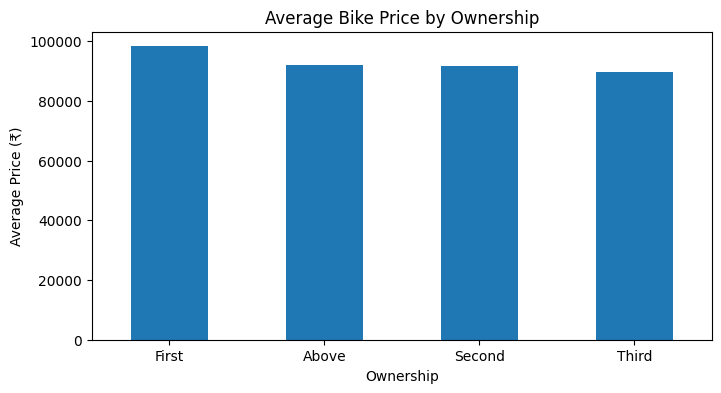

In [47]:
avg_price_ownership.plot(kind="bar", figsize=(8, 4))
plt.title("Average Bike Price by Ownership")
plt.xlabel("Ownership")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=0)
plt.show()

**Q15. Which locations have the highest number of high-priced bikes?**

In [27]:
high_price_bikes = df[df["price"] > 200000]
high_price_location = high_price_bikes["location"].value_counts().head(10)
print(high_price_location)

location
Bangalore    8
Delhi        6
Hyderabad    5
Kolkata      3
Noida        2
Mumbai       2
Pune         2
Ahmedabad    2
Thane        1
Guwahati     1
Name: count, dtype: int64


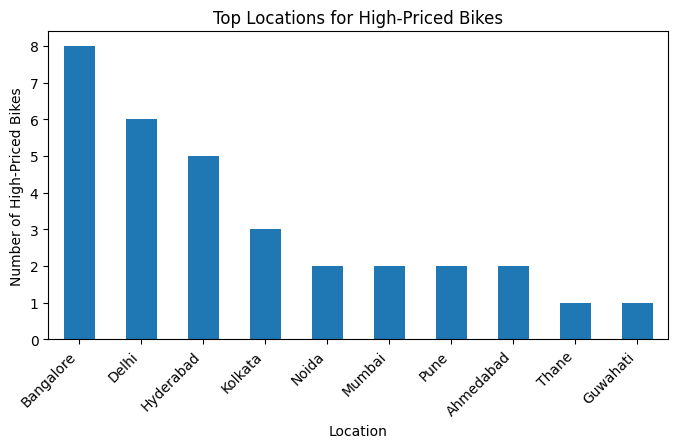

In [46]:
high_price_location.plot(kind="bar", figsize=(8, 4))
plt.title("Top Locations for High-Priced Bikes")
plt.xlabel("Location")
plt.ylabel("Number of High-Priced Bikes")
plt.xticks(rotation=45, ha="right")
plt.show()

**Q16. What is the relationship between ownership and kilometres driven?**

In [29]:
avg_km_ownership = df.groupby("ownership")["km_driven"].mean().sort_values(ascending=False)
print(avg_km_ownership)

ownership
Above     49300.000000
Third     45718.750000
Second    32278.060241
First     25359.391481
Name: km_driven, dtype: float64


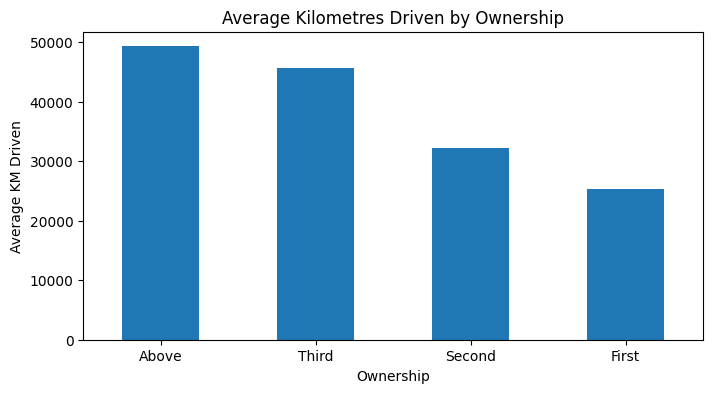

In [45]:
avg_km_ownership.plot(kind="bar", figsize=(8, 4))
plt.title("Average Kilometres Driven by Ownership")
plt.xlabel("Ownership")
plt.ylabel("Average KM Driven")
plt.xticks(rotation=0)
plt.show()

**Q17. Which bike models have the highest average price?**

In [31]:
avg_price_bike = (df.groupby("bike_name")["price"].mean().sort_values(ascending=False) .head(10))
print(avg_price_bike)

bike_name
SR125                                        900000.0
2023 Hero Splendor Plus i3s                  850000.0
2015 Ducati Monster 795 STD                  685000.0
2022 Kawasaki Z650RS                         650000.0
2019 Benelli TNT 600i BS4 ABS BS4            470000.0
2018 Harley-Davidson Street 750 STD          450000.0
2023 Kawasaki Ninja 300                      365000.0
2019 Harley-Davidson Street 750 BS6          350000.0
2015 Benelli TNT 600i BS4 Limited Edition    340000.0
2022 BMW G 310 RR Style Sport                310000.0
Name: price, dtype: float64


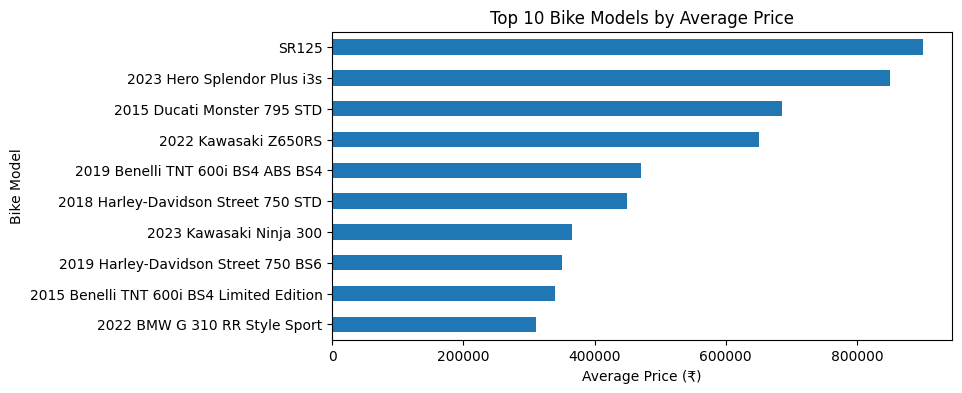

In [44]:
avg_price_bike.sort_values().plot(kind="barh",figsize=(8, 4))
plt.title("Top 10 Bike Models by Average Price")
plt.xlabel("Average Price (₹)")
plt.ylabel("Bike Model")
plt.show()

**Q18. Which locations have the widest price range?**

In [33]:
location_stats = df.groupby("location")["price"].agg( ["count", "min", "max"])
location_stats["price_range"] = ( location_stats["max"] - location_stats["min"])
location_range = ( location_stats[location_stats["count"] >= 5].sort_values("price_range", ascending=False).head(10))
print(location_range)

           count    min     max  price_range
location                                    
Bangalore     57  25000  850000       825000
Delhi        108  17000  685000       668000
Mumbai        61  17000  365000       348000
Pune          43  10203  350000       339797
Hyderabad     38  10000  280000       270000
Noida         24  20000  275000       255000
Gurgaon       16  28000  275000       247000
Kolkata       32  15000  250000       235000
Ahmedabad     14  35000  230000       195000
Jaipur         9  20000  210000       190000


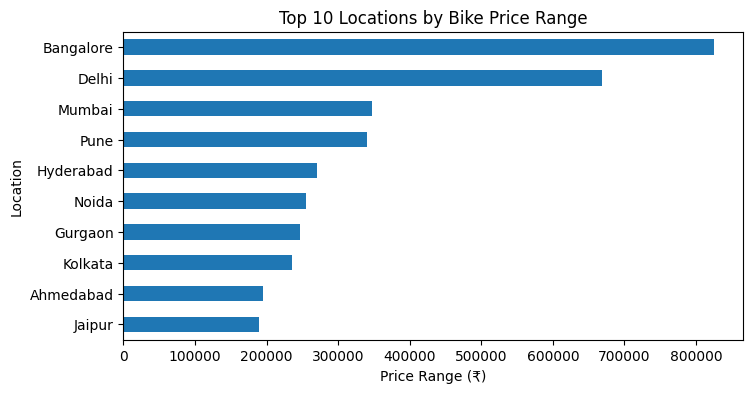

In [43]:
location_range["price_range"].sort_values().plot(kind="barh",figsize=(8, 4))
plt.title("Top 10 Locations by Bike Price Range")
plt.xlabel("Price Range (₹)")
plt.ylabel("Location")
plt.show()

**Q19. How are bikes distributed across price ranges?**

In [35]:
price_bins = [0, 50000, 100000, 200000, float("inf")]
price_labels = ["Under ₹50K","₹50K–₹1L","₹1L–₹2L", "Above ₹2L"]
df["price_range"] = pd.cut(df["price"],bins=price_bins,labels=price_labels,right=False)
price_distribution = df["price_range"].value_counts().reindex(price_labels)
print(price_distribution)

price_range
Under ₹50K    185
₹50K–₹1L      197
₹1L–₹2L       166
Above ₹2L      49
Name: count, dtype: int64


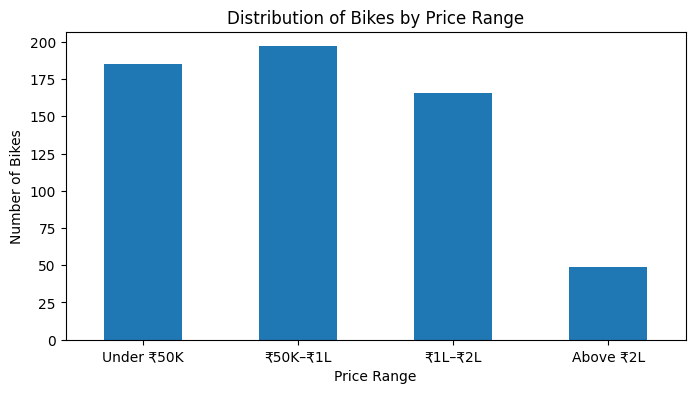

In [42]:
price_distribution.plot(kind="bar",figsize=(8,4))
plt.title("Distribution of Bikes by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Bikes")
plt.xticks(rotation=0)
plt.show()

**Q20. How are bikes distributed across kilometre ranges?**

In [41]:
km_bins = [0, 10000, 25000, 50000, float("inf")]
km_labels = ["Under 10K km","10K–25K km","25K–50K km","Above 50K km"]
df["km_range"] = pd.cut(df["km_driven"],bins=km_bins, labels=km_labels,right=False)
km_distribution = df["km_range"].value_counts().reindex(km_labels)
print(km_distribution)

km_range
Under 10K km    123
10K–25K km      191
25K–50K km      188
Above 50K km     95
Name: count, dtype: int64


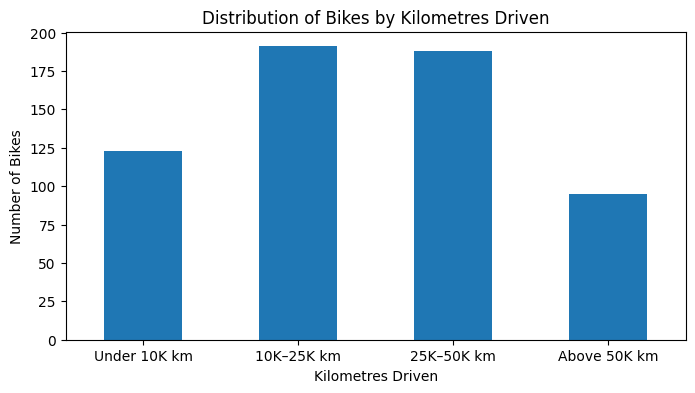

In [40]:
km_distribution.plot(kind="bar",figsize=(8, 4))
plt.title("Distribution of Bikes by Kilometres Driven")
plt.xlabel("Kilometres Driven")
plt.ylabel("Number of Bikes")
plt.xticks(rotation=0)
plt.show()

#### Key Insights
- The dataset contains 597 unique used-bike listings after data cleaning.
- The ₹50K–₹1L price range has the highest number of listings, followed by the ₹1L–₹2L range.
- First-owner bikes dominate the dataset, with 493 listings, compared with 83 second-owner and 16 third-owner bikes.
- First-owner bikes have the highest average listed price, at approximately ₹98,282.
- Bikes with higher ownership generally have higher average kilometres driven. First-owner bikes have the lowest average usage.
- There is a negative relationship between kilometres driven and price (correlation ≈ -0.309), indicating that bikes with higher mileage generally tend to have lower prices.
- Delhi has the highest number of listings, followed by Mumbai, Bangalore, Pune and Hyderabad.
- Bangalore has the highest number of high-priced bikes above ₹2 lakh, followed by Delhi and Hyderabad.
- Bangalore also has the widest price range, showing a large variety of bikes from lower-priced to premium listings.
- Most bikes have 10K–50K kilometres driven, indicating that moderate-mileage bikes form the major portion of the dataset.
- No single bike model dominates the listings. The dataset contains a wide variety of bike models, indicating diverse customer and inventory segments.
- A small number of premium listings have prices above ₹5 lakh, creating a large difference between the typical bike price and the maximum listed price.
#### Business Recommendations
   - Focus marketing and inventory strategies on the ₹50K–₹2L price segment, as it contains the majority of listings.
   - Provide clear filters for price, kilometres driven and ownership to help customers find suitable bikes quickly.
   - Highlight first-owner bikes as a separate category because they represent the majority of available listings.
   - Create separate categories such as Budget, Mid-Range and Premium Bikes based on price ranges.
   - Give greater visibility to bikes with 10K–50K kilometres, as this represents the largest mileage segment.
   - Use ownership, kilometres driven, bike model and location together when analyzing or determining bike prices.
   - Develop city-specific strategies for major markets such as Delhi, Mumbai, Bangalore, Pune and Hyderabad.
   - Create a dedicated Premium Bikes section for bikes priced above ₹2 lakh.
   - Investigate unusually high-priced listings separately before using them as benchmarks for general used-bike pricing.
   - Use the EDA results to improve inventory planning, customer segmentation, pricing analysis and targeted marketing.